# Trabajo Práctico N.º 1
## Análisis y visualización de datos: Black Friday

La idea de este TP es meterme de lleno con el dataset de Black Friday que compartió
ABC Private Limited. Todavía no voy a armar ningún modelo (eso queda para un TP
posterior), lo que quiero acá es entender bien con qué datos cuento: si son
suficientes, si son confiables, qué representan y qué podría llegar a servir el día
de mañana para predecir `Purchase` en pares (cliente, producto) que todavía no
existen en el dataset.

Voy a ir punto por punto siguiendo la consigna (1a-1e y 2a-2g) y dejando después de
cada análisis una conclusión escrita.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style('whitegrid')

In [5]:
data = pd.read_csv('datos/bf_dataset.csv')

In [6]:
data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,NaN,NaN,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,NaN,NaN,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,NaN,NaN,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,NaN,NaN,365


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB


# 1. Familiarización con el dataset

## a) Datos disponibles

In [8]:
data.dtypes

User_ID                         int64
Product_ID                        str
Gender                            str
Age                               str
Occupation                      int64
City_Category                     str
Stay_In_Current_City_Years        str
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Product_Category_3            float64
Purchase                        int64
dtype: object

Mirando los dtypes de pandas, en principio parecen numéricas:
- ``User_ID``
- ``Occupation``
- ``Marital_Status``
- ``Product_Category_1``
- ``Product_Category_2``
- ``Product_Category_3``
- ``Purchase``

Y categóricas (`object`):
- ``Product_ID``
- ``Gender``
- ``Age``
- ``City_Category``
- ``Stay_In_Current_City_Years``

Pero ojo, que pandas las lea como número no significa que estadísticamente lo sean.
``User_ID``, ``Occupation``, ``Marital_Status`` y las tres ``Product_Category_*``
son en realidad **códigos categóricos**: no tiene sentido sacarles un promedio ni
pensar que "categoría 8" es el doble de "categoría 4". La única que es
verdaderamente numérica (una magnitud, con orden y escala real) es ``Purchase``.

In [9]:
data['Occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

In [10]:
data['Product_Category_1'].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9, 20, 19])

Como sospechaba, son enteros que van de 0 a 20 sin ningún orden evidente (están
enmascarados según el diccionario de datos), así que las trato como categóricas
aunque estén codificadas como números.

Ahora, pensando en la naturaleza de cada variable:

- **Demográficas**: ``Gender``, ``Age``, ``Occupation``, ``Marital_Status``.
- **Geográficas**: ``City_Category``, ``Stay_In_Current_City_Years``.
- **De producto**: ``Product_ID``, ``Product_Category_1``, ``Product_Category_2``,
  ``Product_Category_3``.
- **De comportamiento de compra**: en el fondo la única que registra directamente
  comportamiento es ``Purchase``. ``Stay_In_Current_City_Years`` podría dar una
  pista indirecta (alguien recién mudado capaz compra distinto que alguien
  asentado hace años), pero es más geográfica que de comportamiento en sí.
- **Identificadores**: ``User_ID`` (cliente) y ``Product_ID`` (producto). No
  aportan información de negocio en sí mismos, pero son claves para poder
  agrupar y, a futuro, para el modelo (por ejemplo como categoría de alta
  cardinalidad o para hacer target encoding).

## b) Identificación de clientes

In [11]:
data['User_ID'].nunique()

5891

In [12]:
data.shape[0]

550068

Sí, ``User_ID`` identifica de manera única a cada cliente. Tenemos **5891 clientes
únicos** sobre 550068 filas, es decir que en promedio cada cliente aparece
muchísimas veces en el dataset (~93 filas por cliente). Esto tiene sentido: cada
fila no es "un cliente", es "un item que un cliente compró", así que un mismo
``User_ID`` se repite tantas veces como productos distintos haya comprado.

## c) Información temporal

No hay ninguna columna de fecha ni timestamp en el dataset. Lo único que tenemos
es qué compró cada cliente y cuánto pagó, pero no *cuándo* lo compró (más allá de
que el enunciado dice que es "del último mes").

Esto tiene implicancias importantes:
- No puedo estudiar estacionalidad ni tendencia a lo largo del tiempo (¿el gasto
  sube cerca de fin de mes? ¿hay un pico un día particular del Black Friday
  propiamente dicho? No lo sé).
- No puedo saber si las filas de un mismo ``User_ID`` corresponden a una sola
  sesión de compra o a compras separadas en distintos momentos del mes.
- Para el futuro modelo, esto significa que no voy a poder construir features
  temporales (recencia, frecuencia en el tiempo, etc.), lo cual es una limitación
  real si en algún momento se quisiera pensar en algo más parecido a un sistema de
  recomendación con componente temporal.

En limpio: es una limitación conocida, no bloquea armar un modelo de "cuánto
gastaría este cliente en este producto", pero sí bloquea cualquier pregunta que
tenga que ver con "cuándo" ofrecer algo.

## d) Datos nulos y suficiencia de los datos

In [13]:
data.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [14]:
(data.isnull().sum() / data.shape[0] * 100).round(2)

User_ID                        0.00
Product_ID                     0.00
Gender                         0.00
Age                            0.00
Occupation                     0.00
City_Category                  0.00
Stay_In_Current_City_Years     0.00
Marital_Status                 0.00
Product_Category_1             0.00
Product_Category_2            31.57
Product_Category_3            69.67
Purchase                       0.00
dtype: float64

Tenemos nulos solamente en ``Product_Category_2`` (31.57%) y ``Product_Category_3``
(69.67%). El resto de las columnas está completo.

La interpretación de negocio más razonable es que no todos los productos tienen
subcategorías: un producto puede tener una sola categoría principal y no tener
nada más específico que informar, entonces esas columnas quedan vacías. No parece
un error de carga de datos sino algo estructural del catálogo (categorías
jerárquicas donde no siempre se llega al tercer nivel).

Sobre la suficiencia: 550068 filas y 5891 clientes es un volumen razonable para
empezar a pensar en un modelo, pero hay que tener cuidado con una cosa: como cada
cliente aparece muchas veces, no son 550068 observaciones "independientes" en el
sentido de clientes distintos. Para entrenar y validar un modelo más adelante va a
ser importante separar por ``User_ID`` (que un mismo cliente no esté a la vez en
train y en test) para no inflar artificialmente la performance.

## e) Variable objetivo

In [15]:
data['Purchase'].describe()

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64

In [16]:
data['Purchase'].nunique()

18105

Sí, tenemos la columna objetivo: ``Purchase``. Es una variable numérica continua
(o al menos con muchísimos valores distintos, 18105 valores únicos), sin nulos, lo
que la hace apta para un problema de regresión supervisada.

Desde el punto de vista de negocio, ``Purchase`` representa el monto que un
cliente pagó por un producto (o por la combinación cliente-producto de esa fila).
Es exactamente lo que la empresa quiere poder anticipar para armar ofertas
personalizadas: "¿cuánto estaría dispuesto a gastar este cliente en este producto?"

# 2. Análisis y visualización de los datos

## a) Resumen estadístico

In [17]:
data['Purchase'].min()

np.int64(12)

In [18]:
data['Purchase'].max()

np.int64(23961)

In [19]:
data['Purchase'].mean()

np.float64(9263.968712959126)

In [20]:
data['Purchase'].median()

np.float64(8047.0)

In [21]:
data['Purchase'].quantile([0.25, 0.5, 0.75])

0.25     5823.0
0.50     8047.0
0.75    12054.0
Name: Purchase, dtype: float64

In [22]:
data['Purchase'].describe()

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64

Con esto alcanza para la única variable realmente numérica del dataset. El resto
de las "numéricas" (``Occupation``, ``Marital_Status``, ``Product_Category_1/2/3``)
son códigos categóricos, así que no tiene sentido de negocio calcularles media o
cuantiles (¿qué significaría que la ocupación promedio es 8.08? nada).

Lo que sí puedo decir de ``Purchase``: el gasto mínimo es 12, el máximo 23961, la
media (9263.97) está por encima de la mediana (8047), lo que ya me hace sospechar
que la distribución tiene cola hacia la derecha (hay compras grandes que empujan
la media para arriba).

## b) Distribución de las variables

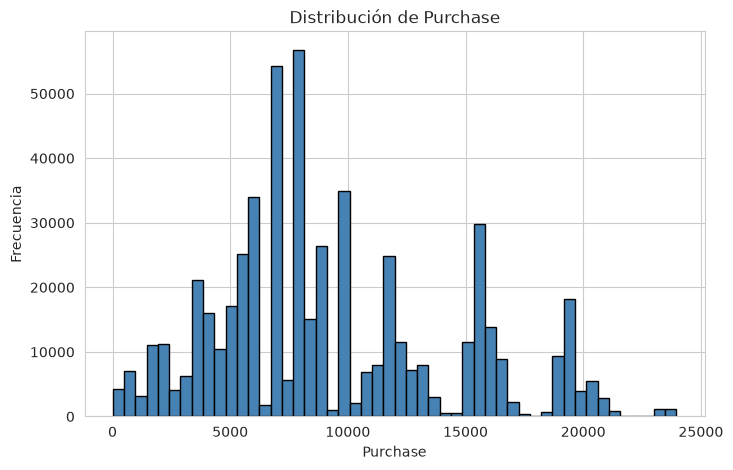

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(data['Purchase'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribución de Purchase')
plt.xlabel('Purchase')
plt.ylabel('Frecuencia')
plt.show()

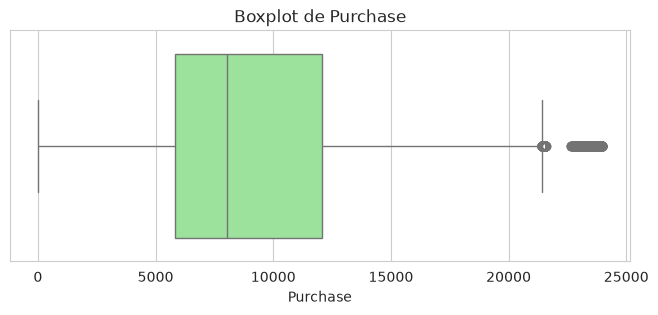

In [24]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=data['Purchase'], color='lightgreen')
plt.title('Boxplot de Purchase')
plt.show()

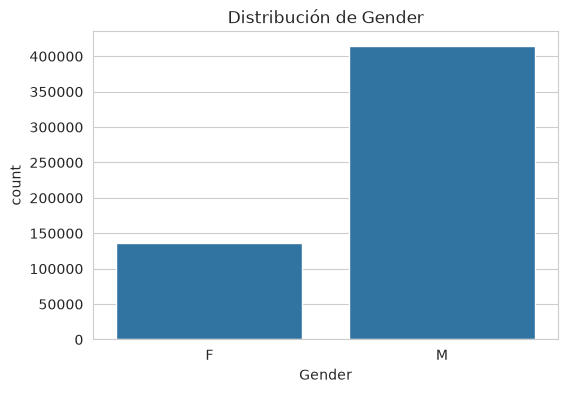

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=data)
plt.title('Distribución de Gender')
plt.show()

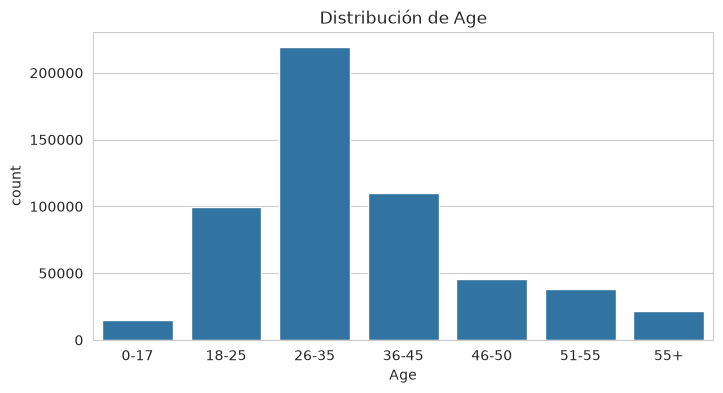

In [26]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Age', data=data, order=sorted(data['Age'].unique()))
plt.title('Distribución de Age')
plt.show()

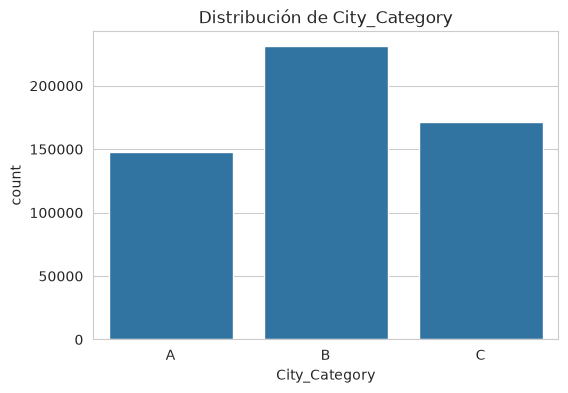

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(x='City_Category', data=data, order=['A', 'B', 'C'])
plt.title('Distribución de City_Category')
plt.show()

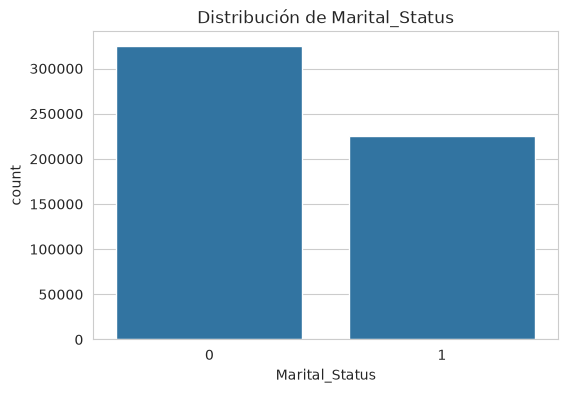

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Marital_Status', data=data)
plt.title('Distribución de Marital_Status')
plt.show()

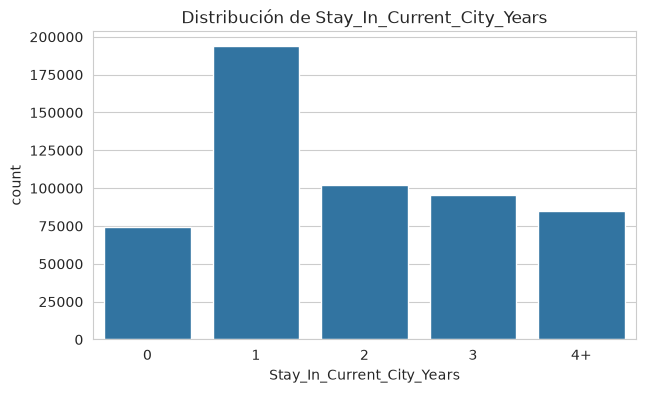

In [29]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Stay_In_Current_City_Years', data=data,
              order=['0', '1', '2', '3', '4+'])
plt.title('Distribución de Stay_In_Current_City_Years')
plt.show()

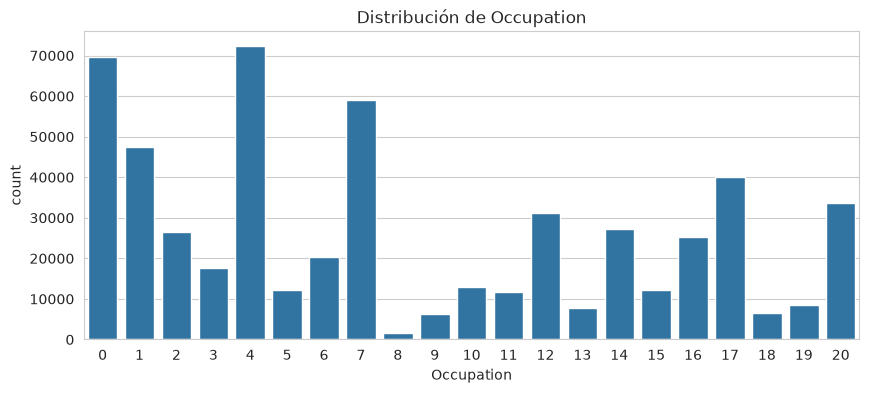

In [30]:
plt.figure(figsize=(10, 4))
sns.countplot(x='Occupation', data=data, order=sorted(data['Occupation'].unique()))
plt.title('Distribución de Occupation')
plt.show()

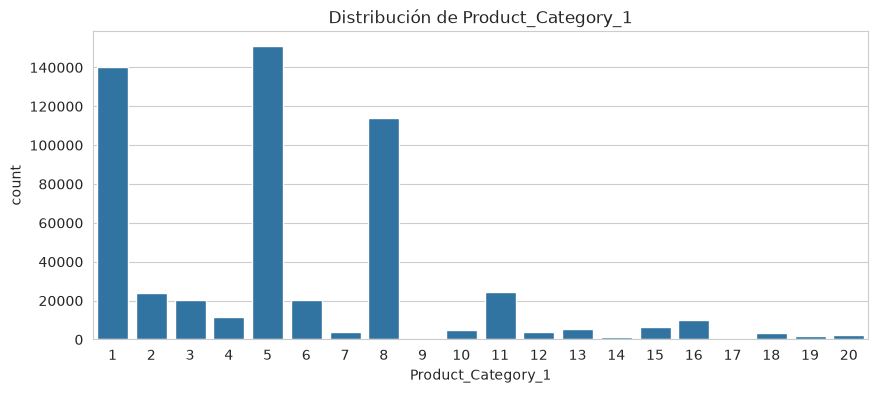

In [31]:
plt.figure(figsize=(10, 4))
sns.countplot(x='Product_Category_1', data=data,
              order=sorted(data['Product_Category_1'].unique()))
plt.title('Distribución de Product_Category_1')
plt.show()

In [32]:
data['Product_Category_2'].isnull().sum()

np.int64(173638)

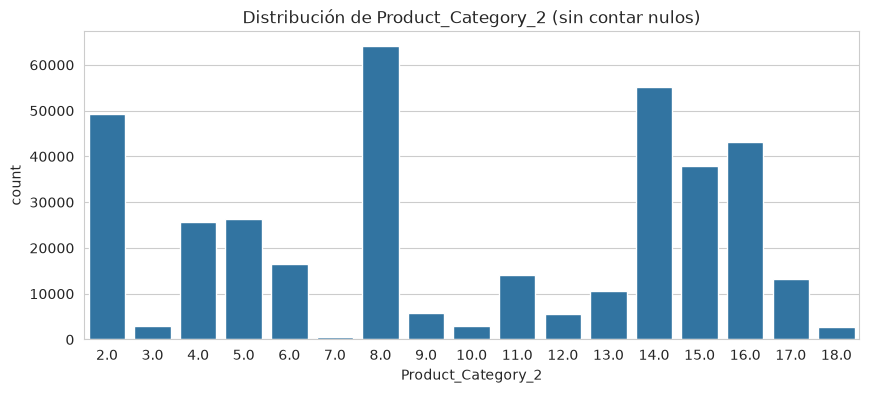

In [33]:
plt.figure(figsize=(10, 4))
sns.countplot(x='Product_Category_2', data=data,
              order=sorted(data['Product_Category_2'].dropna().unique()))
plt.title('Distribución de Product_Category_2 (sin contar nulos)')
plt.show()

Algunas cosas que veo acá:
- ``Purchase`` tiene un histograma con cola a la derecha, con un grupo grande de
  compras chicas/medias y menos casos de compras muy altas. También se nota un
  pico raro cerca de 15000-16000, como si hubiera precios "típicos" de ciertos
  productos que se repiten mucho.
- El boxplot de ``Purchase`` no muestra outliers extremos marcados aparte (no hay
  puntos sueltos más allá de los bigotes), lo cual tiene sentido: es una cola
  larga pero continua, no valores puntuales rarísimos.
- En ``Gender`` hay bastante desbalance: muchas más compras de hombres que de
  mujeres.
- En ``Age`` el grupo 26-35 concentra la mayor cantidad de compras, después
  36-45 y 18-25.
- En ``City_Category`` la categoría B tiene más filas, pero (como voy a ver más
  adelante) eso no significa necesariamente que tenga más clientes únicos.
- ``Occupation`` y ``Product_Category_1`` tienen categorías bastante desparejas
  en frecuencia, con algunas ocupaciones/categorías muy por encima del resto.
- No veo datos faltantes en ninguna de estas variables categóricas (solo en
  Product_Category_2 y 3, como ya había visto en el punto 1d).

## c) Distribución de la variable objetivo

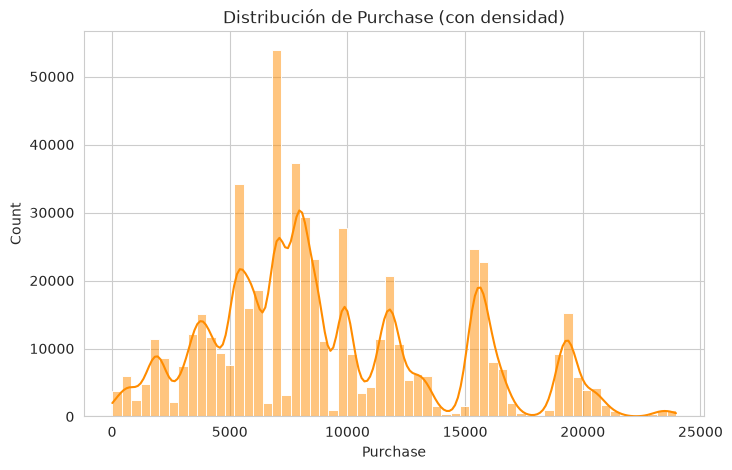

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(data['Purchase'], bins=60, kde=True, color='darkorange')
plt.title('Distribución de Purchase (con densidad)')
plt.show()

In [35]:
data['Purchase'].skew()

np.float64(0.6001400037087126)

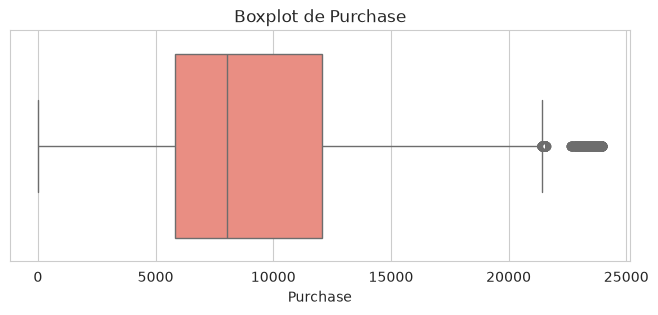

In [36]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=data['Purchase'], color='salmon')
plt.title('Boxplot de Purchase')
plt.show()

In [37]:
q1 = data['Purchase'].quantile(0.25)
q3 = data['Purchase'].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
limite_superior

np.float64(21400.5)

In [38]:
(data['Purchase'] > limite_superior).sum()

np.int64(2677)

El skew da 0.6, positivo, lo que confirma lo que sospechaba en el punto 2a: la
distribución está sesgada a la derecha (hay más compras "moderadas" y una cola de
compras más grandes, no al revés).

Usando la regla del rango intercuartílico (Q3 + 1.5*IQR), técnicamente no hay
ningún valor por encima de ese límite (el máximo real, 23961, queda por debajo),
así que en términos estrictamente estadísticos no hay outliers univariados
extremos en ``Purchase``. Lo que sí hay es una distribución bastante asimétrica,
con compras que van desde 12 hasta casi 24000.

En cuanto al comportamiento general del gasto: la mayoría de las compras se
concentran en un rango medio-bajo (entre 5823 y 12054, que es el rango
intercuartílico), con una minoría de compras que se van hacia montos más altos.
Para un futuro modelo, este sesgo es un dato importante: capaz conviene evaluar
aplicar una transformación logarítmica a ``Purchase`` antes de modelar, para que
los algoritmos no se vean tan afectados por esa cola.

## d) Comparación del comportamiento de compra

### 1. ¿Cuál es la distribución de los clientes por género?

In [39]:
data.groupby('Gender')['User_ID'].nunique()

Gender
F    1666
M    4225
Name: User_ID, dtype: int64

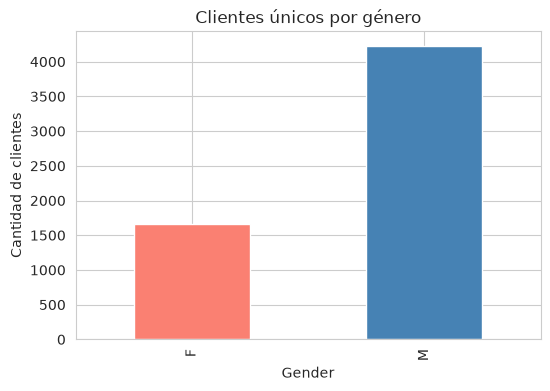

In [40]:
plt.figure(figsize=(6, 4))
data.groupby('Gender')['User_ID'].nunique().plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Clientes únicos por género')
plt.ylabel('Cantidad de clientes')
plt.show()

Ojo con la diferencia entre "filas" y "clientes": en filas los hombres son mucho
más (414259 vs 135809), y en clientes únicos la proporción es parecida
(4225 hombres vs 1666 mujeres). O sea que no es que haya pocas mujeres comprando
mucho o muchas comprando poco, la proporción de clientes por género se mantiene
más o menos parecida a la proporción de filas: hay bastante más presencia
masculina en el dataset tanto en clientes como en transacciones.

### 2. ¿Qué grupos etarios presentan mayor gasto?

In [41]:
data.groupby('Age')['Purchase'].mean().sort_values(ascending=False)

Age
51-55    9534.808031
55+      9336.280459
36-45    9331.350695
26-35    9252.690633
46-50    9208.625697
18-25    9169.663606
0-17     8933.464640
Name: Purchase, dtype: float64

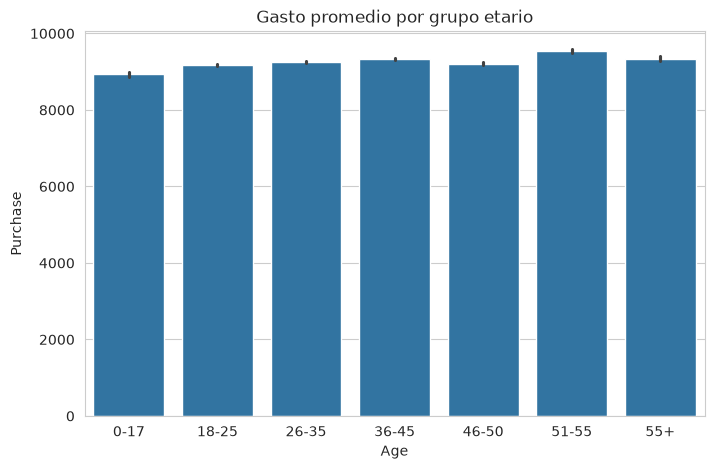

In [42]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Age', y='Purchase', data=data,
            order=sorted(data['Age'].unique()), estimator=np.mean)
plt.title('Gasto promedio por grupo etario')
plt.show()

El grupo que más gasta en promedio es 51-55, seguido de cerca por 55+ y 36-45. El
grupo que menos gasta en promedio es 0-17. Igual las diferencias entre grupos no
son enormes (todas rondan entre 8900 y 9550), así que la edad sola no separa
demasiado el gasto promedio por compra.

### 3. ¿Dónde se encuentra el mayor número de clientes?

In [43]:
data.groupby('City_Category')['User_ID'].nunique()

City_Category
A    1045
B    1707
C    3139
Name: User_ID, dtype: int64

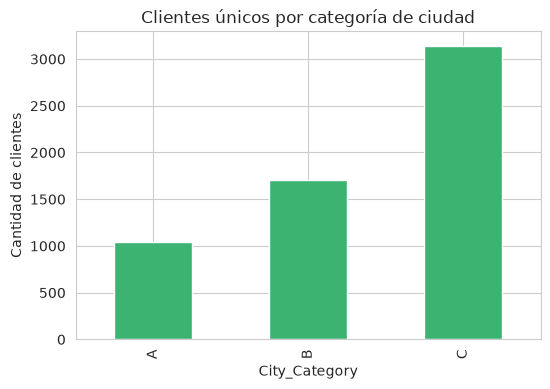

In [44]:
plt.figure(figsize=(6, 4))
data.groupby('City_Category')['User_ID'].nunique().plot(kind='bar', color='mediumseagreen')
plt.title('Clientes únicos por categoría de ciudad')
plt.ylabel('Cantidad de clientes')
plt.show()

La mayor cantidad de clientes únicos está en la categoría C (3139 clientes),
seguida por B (1707) y A (1045). Es interesante porque en el punto 2b había visto
que la ciudad B tenía más *filas* que C, pero acá se ve que C tiene más
*clientes*. Esto sugiere que, en la ciudad B, cada cliente compra más items en
promedio que en C.

### 4. ¿Cuántos productos únicos tiene el dataset?

In [45]:
data['Product_ID'].nunique()

3631

Hay 3631 productos únicos en el dataset.

### 5. ¿Cuáles son las categorías de productos más frecuentes?

In [46]:
data['Product_Category_1'].value_counts().head(10)

Product_Category_1
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
Name: count, dtype: int64

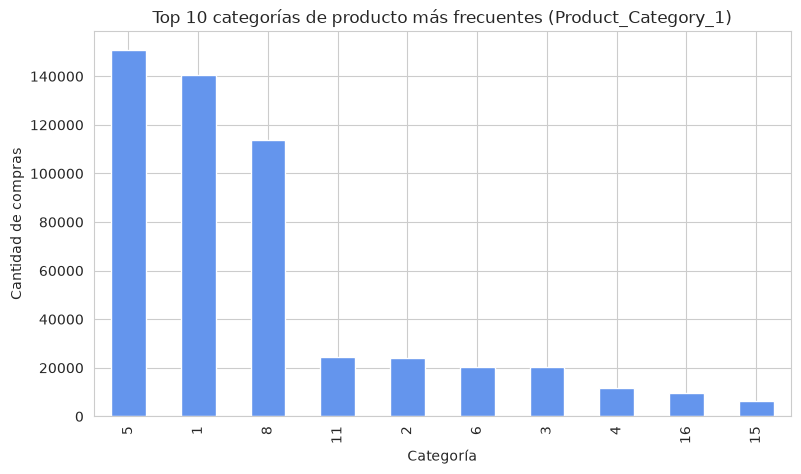

In [47]:
plt.figure(figsize=(9, 5))
data['Product_Category_1'].value_counts().head(10).plot(kind='bar', color='cornflowerblue')
plt.title('Top 10 categorías de producto más frecuentes (Product_Category_1)')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de compras')
plt.show()

Las categorías más frecuentes son la 5, la 1 y la 8, muy por encima del resto.
Entre las tres suman más de la mitad de las filas del dataset. El resto de las
categorías tiene una presencia bastante más chica.

### 6. ¿Qué combinaciones de categorías están asociadas a un mayor gasto?

In [48]:
combo_gasto = data.groupby(['Product_Category_1', 'Product_Category_2'])['Purchase'].mean()
combo_gasto.sort_values(ascending=False).head(10)

Product_Category_1  Product_Category_2
10                  14.0                  20113.225000
                    16.0                  19704.598506
                    13.0                  19610.779787
                    15.0                  19475.085308
                    11.0                  19206.000000
15                  17.0                  18951.667571
6                   10.0                  16772.858116
7                   17.0                  16041.265306
6                   16.0                  15973.824675
                    8.0                   15837.501698
Name: Purchase, dtype: float64

In [49]:
combo_conteo = data.groupby(['Product_Category_1', 'Product_Category_2']).size()
combo_conteo.loc[combo_gasto.sort_values(ascending=False).head(10).index]

Product_Category_1  Product_Category_2
10                  14.0                    240
                    16.0                   1071
                    13.0                   1880
                    15.0                   1477
                    11.0                      1
15                  17.0                    737
6                   10.0                   2643
7                   17.0                     98
6                   16.0                   4004
                    8.0                   12071
dtype: int64

Las combinaciones con mayor gasto promedio son, por ejemplo, categoría 10 con
subcategoría 14, 16 o 13 (todas rondando los 19000-20000 de gasto promedio), y la
combinación 15-17. Pero hay que tener cuidado: algunas de estas combinaciones
tienen muy pocos casos (como 10-11 con una sola fila), así que ese promedio no es
muy confiable. Las combinaciones que además tienen un volumen razonable de casos
(varios cientos o miles), como 6-8 o 6-16, son una señal más sólida de que esa
combinación de categorías realmente está asociada a compras más caras.

### 7. ¿Cuáles son los productos con mayor monto de compra?

In [50]:
data.groupby('Product_ID')['Purchase'].sum().sort_values(ascending=False).head(10)

Product_ID
P00025442    27995166
P00110742    26722309
P00255842    25168963
P00059442    24338343
P00184942    24334887
P00112142    24216006
P00110942    23639564
P00237542    23425576
P00057642    23102780
P00010742    22164153
Name: Purchase, dtype: int64

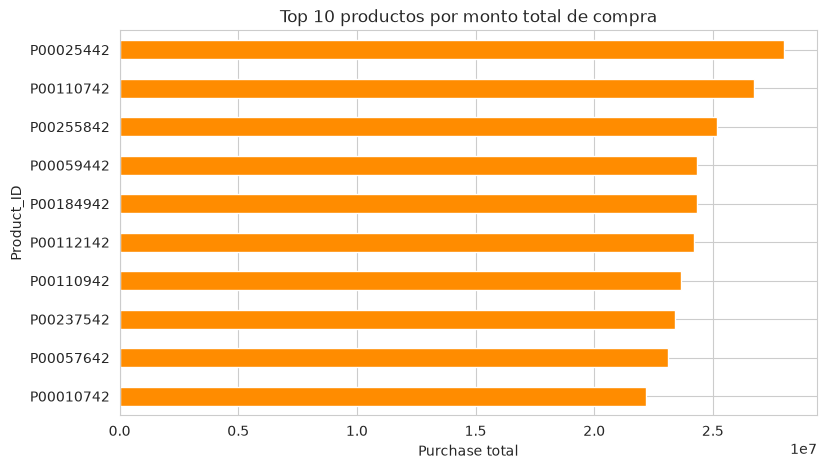

In [51]:
top_productos_por_suma = data.groupby('Product_ID')['Purchase'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 5))
top_productos_por_suma.plot(kind='barh', color='darkorange')
plt.title('Top 10 productos por monto total de compra')
plt.xlabel('Purchase total')
plt.gca().invert_yaxis()
plt.show()

Acá conviene distinguir dos preguntas distintas: "qué producto generó más plata
en total" (suma de Purchase) vs "qué producto es más caro en promedio" (esto lo
vi parcialmente en el punto anterior con las combinaciones de categoría). Por
suma total, el producto P00025442 es el que más generó, seguido de P00110742 y
P00255842, todos por encima de los 22 millones en Purchase acumulado. Esto tiene
que ver tanto con el precio del producto como con cuántas veces se vendió.

### 8. ¿Cómo se comportan los clientes con valores faltantes en Product_Category_2 y Product_Category_3?

In [52]:
data['PC2_falta'] = data['Product_Category_2'].isnull()
data['PC3_falta'] = data['Product_Category_3'].isnull()

In [53]:
data.groupby('PC2_falta')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
PC2_falta,,,,,,,,
False,376430.0,10069.020833,5186.631291,185.0,6105.0,8775.0,15190.0,23961.0
True,173638.0,7518.695389,4142.460056,12.0,5254.0,7075.0,8783.0,23959.0


In [54]:
data.groupby('PC3_falta')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
PC3_falta,,,,,,,,
False,166821.0,11658.114980,5082.287959,185.0,7869.0,11756.0,15626.0,23959.0
True,383247.0,8221.836943,4624.898598,12.0,5328.0,7449.0,9882.0,23961.0


In [55]:
data.groupby(['PC2_falta', 'PC3_falta']).size()

PC2_falta  PC3_falta
False      False        166821
           True         209609
True       True         173638
dtype: int64

### 9. ¿Cómo se comporta el gasto en presencia de datos faltantes?

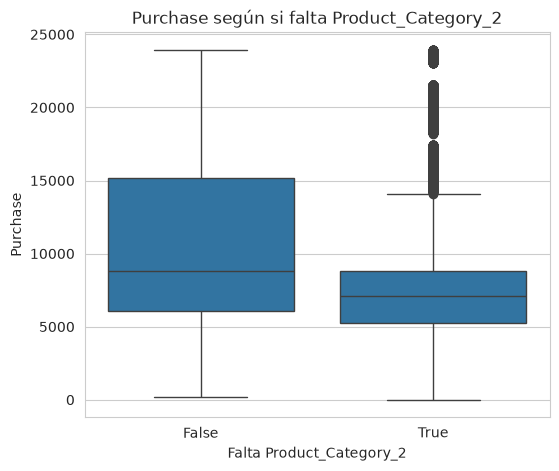

In [56]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='PC2_falta', y='Purchase', data=data)
plt.title('Purchase según si falta Product_Category_2')
plt.xlabel('Falta Product_Category_2')
plt.show()

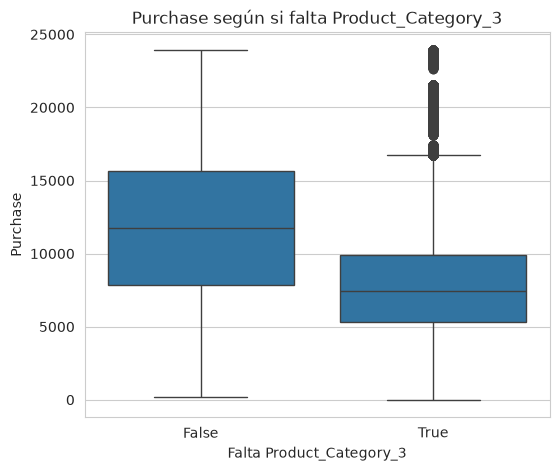

In [57]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='PC3_falta', y='Purchase', data=data)
plt.title('Purchase según si falta Product_Category_3')
plt.xlabel('Falta Product_Category_3')
plt.show()

In [58]:
data.groupby(['PC2_falta', 'PC3_falta'])['Purchase'].mean()

PC2_falta  PC3_falta
False      False        11658.114980
           True          8804.312377
True       True          7518.695389
Name: Purchase, dtype: float64

Esto me parece uno de los hallazgos más interesantes de todo el análisis: la
falta de subcategoría **no es aleatoria respecto del gasto**. Cuando faltan
ambas subcategorías (producto con una sola categoría), el gasto promedio es el
más bajo (7518). Cuando está la categoría 2 pero no la 3, el gasto sube
(8804). Y cuando están las tres categorías completas, el gasto promedio es el
más alto (11658).

Esto tiene bastante sentido de negocio: productos con más niveles de categoría
probablemente sean productos más "complejos" o de mayor valor (electrónica con
subtipos, por ejemplo), mientras que productos con una sola categoría son más
genéricos y baratos. Esto además significa que el patrón de nulos en sí mismo es
información útil: no conviene simplemente imputar o descartar esas columnas sin
más, un indicador booleano de "tiene o no tiene subcategoría" podría ser una
feature valiosa para el futuro modelo.

## e) Relación entre variables

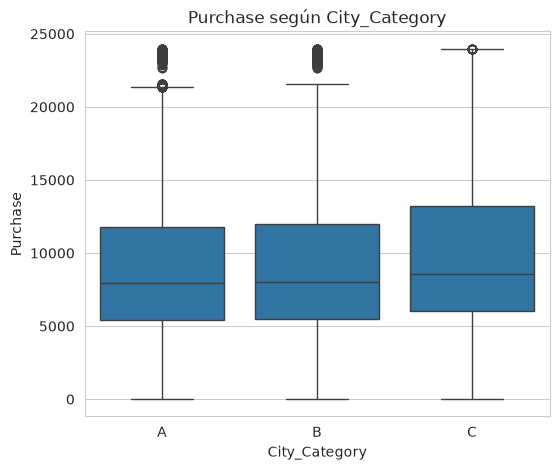

In [59]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='City_Category', y='Purchase', data=data, order=['A', 'B', 'C'])
plt.title('Purchase según City_Category')
plt.show()

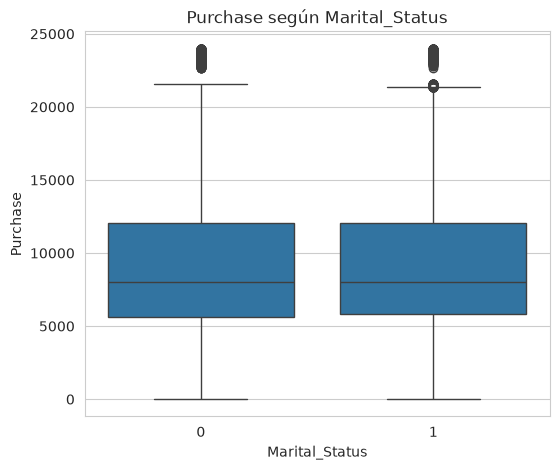

In [60]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Marital_Status', y='Purchase', data=data)
plt.title('Purchase según Marital_Status')
plt.show()

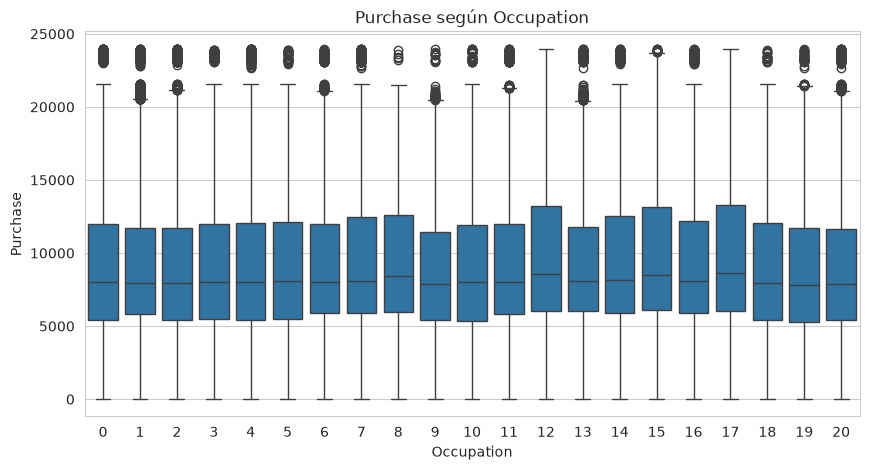

In [61]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Occupation', y='Purchase', data=data,
            order=sorted(data['Occupation'].unique()))
plt.title('Purchase según Occupation')
plt.show()

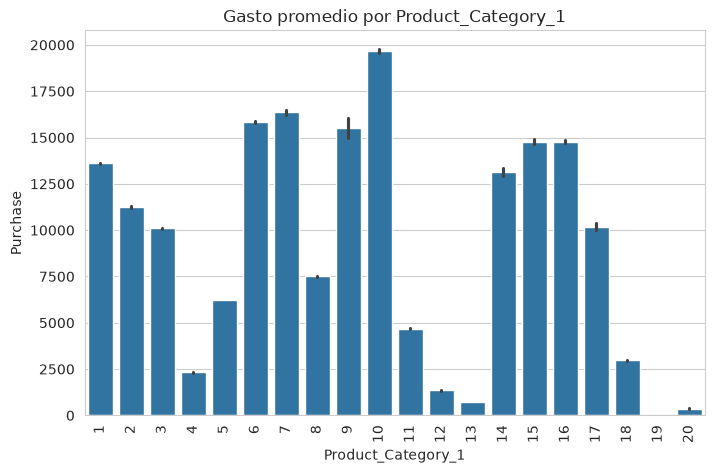

In [62]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Product_Category_1', y='Purchase', data=data,
            order=sorted(data['Product_Category_1'].unique()), estimator=np.mean)
plt.title('Gasto promedio por Product_Category_1')
plt.xticks(rotation=90)
plt.show()

Con todo lo visto hasta acá, la variable que más separa el gasto claramente es
``Product_Category_1`` (hay categorías que promedian menos de 1000 de Purchase y
otras que promedian casi 20000, una diferencia enorme). ``City_Category`` y
``Marital_Status`` muestran diferencias, pero mucho más sutiles. ``Occupation``
tiene algo de variación entre ocupaciones pero tampoco parece un factor
determinante por sí solo. En cambio, la presencia/ausencia de subcategorías
(punto 2d.9) sí mostró una relación bastante clara con el gasto.

En resumen: el producto en sí (su categoría) es, hasta ahora, el factor más
fuerte asociado al monto de compra, mucho más que las variables puramente
demográficas o geográficas del cliente.

## f) Segmentación del gasto

In [63]:
data['Purchase'].quantile([0.33, 0.66])

0.33     6903.0
0.66    10027.0
Name: Purchase, dtype: float64

In [64]:
data['Segmento_gasto'] = pd.cut(
    data['Purchase'],
    bins=[0, 6903, 10027, data['Purchase'].max()],
    labels=['Bajo', 'Medio', 'Alto']
)

In [65]:
data['Segmento_gasto'].value_counts()

Segmento_gasto
Alto     186966
Medio    181569
Bajo     181533
Name: count, dtype: int64

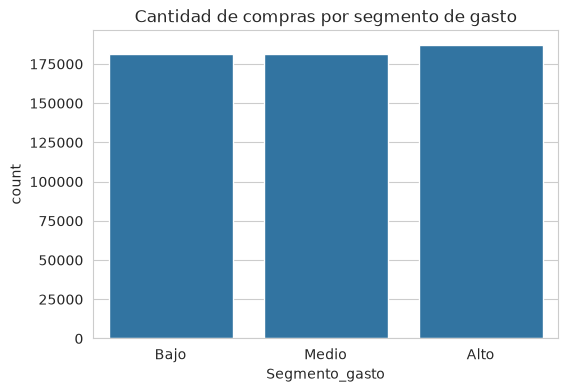

In [66]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Segmento_gasto', data=data, order=['Bajo', 'Medio', 'Alto'])
plt.title('Cantidad de compras por segmento de gasto')
plt.show()

In [67]:
data.groupby('Segmento_gasto')['Product_Category_1'].agg(lambda x: x.value_counts().index[0])

Segmento_gasto
Bajo     5
Medio    5
Alto     1
Name: Product_Category_1, dtype: int64

In [68]:
data.groupby('Segmento_gasto')['Gender'].value_counts(normalize=True)

Segmento_gasto  Gender
Bajo            M         0.736065
                F         0.263935
Medio           M         0.726523
                F         0.273477
Alto            M         0.795465
                F         0.204535
Name: proportion, dtype: float64

In [69]:
data.groupby('Segmento_gasto')['City_Category'].value_counts(normalize=True)

Segmento_gasto  City_Category
Bajo            B                0.433464
                A                0.290079
                C                0.276457
Medio           B                0.415049
                C                0.314828
                A                0.270123
Alto            B                0.412508
                C                0.341378
                A                0.246114
Name: proportion, dtype: float64

In [70]:
data.groupby('Segmento_gasto')[['PC2_falta', 'PC3_falta']].mean()

,PC2_falta,PC3_falta
Segmento_gasto,,
Bajo,0.418756,0.833331
Medio,0.402123,0.809995
Alto,0.131612,0.454093


Corté ``Purchase`` en tres segmentos usando los percentiles 33 y 66 (así quedan
más o menos parejos en cantidad de filas). Algunas diferencias entre segmentos:

- El segmento **Alto** tiene una proporción bastante más baja de nulos en
  ``Product_Category_2`` y ``Product_Category_3`` que el segmento **Bajo**, en
  línea con lo que había visto en el punto 2d.9: los productos con más
  subcategorías tienden a ser los más caros.
- La categoría de producto más común (``Product_Category_1``) que domina en
  cada segmento no es necesariamente la misma, lo que confirma que el segmento
  de gasto está bastante atado al tipo de producto comprado, más que al perfil
  del cliente.
- La distribución por género y por ciudad se mantiene bastante parecida entre
  segmentos, lo que refuerza la idea de que esas variables solas no explican
  demasiado bien a qué segmento de gasto pertenece una compra.

## g) Selección preliminar de variables

Pensando en el futuro modelo (predecir ``Purchase`` para pares cliente-producto),
esto es lo que rescato de todo el análisis:

**Variables que me parecen prometedoras:**
- ``Product_Category_1``: fue, de lejos, la variable con mayor poder de
  separación sobre ``Purchase`` (punto 2e).
- ``Product_Category_2`` y ``Product_Category_3``: aportan información real,
  pero además su sola presencia/ausencia (nulo o no) ya es una señal útil
  (punto 2d.8-9). Habría que pensar bien cómo tratar los nulos (¿imputar con una
  categoría "sin subcategoría" en vez de imputar con la media, por ejemplo?).
- ``City_Category``: mostró diferencias, aunque más leves que las categorías de
  producto.
- ``Occupation``: alguna variación, vale la pena mantenerla como candidata.
- ``Product_ID``: de altísima cardinalidad (3631 valores), no se puede meter
  directo como dummy, pero probablemente convenga algún tipo de encoding
  (target encoding, frecuencia, o agruparlo a través de las categorías).

**Variables que dudo que aporten mucho, al menos solas:**
- ``Gender``, ``Age``, ``Marital_Status``, ``Stay_In_Current_City_Years``:
  mostraron diferencias chicas en el gasto promedio. No las descartaría del
  todo (capaz interactúan con otras variables), pero no parecen ser, por sí
  solas, buenas predictoras.
- ``User_ID``: no es una feature en el sentido de "algo que explique el
  monto", es más bien un identificador. Podría servir para features derivadas
  (por ejemplo, gasto histórico promedio de ese cliente) más que como
  categoría directa.

En síntesis, con lo que vimos en el TP1 parece razonable avanzar hacia un
modelo que se apoye principalmente en las variables de producto
(``Product_Category_1/2/3``, y algún tratamiento de ``Product_ID``), sumando
``City_Category`` y ``Occupation`` como variables de cliente, y evaluando el
resto como candidatas secundarias. La falta de información temporal sigue
siendo una limitación a tener en cuenta, y el sesgo de ``Purchase`` (punto 2c)
sugiere evaluar una transformación logarítmica antes de entrenar cualquier
modelo de regresión.